# Support Ticket Business Insights

**Project:** AI Customer Support & Resolution Assistant  
**Company:** ServeFlow (fictional)  
**Role:** Business Analyst & Product Manager  
**Dataset:** Synthetic support-ticket dataset  

## Objective
Translate support-ticket data into evidence-backed business insights and product opportunities.

The analysis focuses on ticket volume, resolution performance, escalation, SLA breaches, repeat contacts, and customer satisfaction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
DATA_URL = "https://raw.githubusercontent.com/mishtha13/ai-customer-support-resolution-assistant/main/data/raw/support_tickets.csv"

df = pd.read_csv(DATA_URL)

df['created_at'] = pd.to_datetime(df['created_at'])

boolean_cols = ['escalated', 'reopened', 'repeat_contact', 'sla_breached']
for col in boolean_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.lower().map({'true': True, 'false': False})

print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]}')
display(df.head())

Rows: 5,000
Columns: 21


,ticket_id,customer_id,created_at,channel,customer_tier,subject,description,category,sub_category,product_area,priority,agent_id,first_response_time_mins,resolution_time_hours,status,escalated,reopened,repeat_contact,sla_breached,csat_score,resolution_type
0,TKT_004691,CUST_0748,2026-01-01 00:08:00,Email,Standard,Customer wants to update profile information.,Customer wants to update profile information. ...,Account,Login Issue,Identity & Access,Medium,AGT_013,38.87,2.46,Closed,False,False,False,False,5,Knowledge Base
1,TKT_003674,CUST_0493,2026-01-01 00:26:00,Email,Enterprise,Customer needs help configuring the platform.,Customer needs help configuring the platform. ...,Product Usage,How-To Question,Platform Features,High,AGT_020,21.71,9.50,Resolved,False,False,False,False,4,Agent Resolution
2,TKT_002628,CUST_0145,2026-01-01 01:28:00,Email,Professional,Customer reports an application error while us...,Customer reports an application error while us...,Technical,Data Sync,Core Platform,High,AGT_005,41.83,33.79,Resolved,False,False,True,True,3,Technical Fix
3,TKT_002259,CUST_0326,2026-01-01 03:26:00,Live Chat,Professional,Customer says a payment failed and needs help ...,Customer says a payment failed and needs help ...,Billing,Invoice Issue,Payments,Medium,AGT_008,9.97,9.50,Escalated,True,False,False,False,4,Agent Resolution
4,TKT_004111,CUST_0283,2026-01-01 03:42:00,Web Form,Standard,Customer says a payment failed and needs help ...,Customer says a payment failed and needs help ...,Billing,Payment Failure,Payments,Medium,AGT_004,29.30,11.02,Closed,False,False,False,False,4,Customer Follow-up


## 1. Data Quality Check

In [3]:
quality = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique()
})
display(quality.sort_values('missing_values', ascending=False))

print('Duplicate ticket IDs:', df['ticket_id'].duplicated().sum())

,missing_values,missing_pct,unique_values
ticket_id,0,0.00,5000
customer_id,0,0.00,1683
created_at,0,0.00,4948
channel,0,0.00,4
customer_tier,0,0.00,3
subject,0,0.00,32
description,0,0.00,160
category,0,0.00,8
sub_category,0,0.00,32
product_area,0,0.00,8


Duplicate ticket IDs: 0


## 2. Executive KPI Baseline

In [4]:
kpis = pd.Series({
    'Total Tickets': len(df),
    'Avg Resolution Time (hrs)': df['resolution_time_hours'].mean(),
    'Avg First Response (mins)': df['first_response_time_mins'].mean(),
    'Escalation Rate (%)': df['escalated'].mean() * 100,
    'SLA Breach Rate (%)': df['sla_breached'].mean() * 100,
    'Repeat Contact Rate (%)': df['repeat_contact'].mean() * 100,
    'Reopen Rate (%)': df['reopened'].mean() * 100,
    'Average CSAT': df['csat_score'].mean()
})
display(kpis.to_frame('Value'))

,Value
Total Tickets,"5,000.00"
Avg Resolution Time (hrs),10.61
Avg First Response (mins),47.69
Escalation Rate (%),14.64
SLA Breach Rate (%),21.08
Repeat Contact Rate (%),8.36
Reopen Rate (%),5.90
Average CSAT,4.04


## 3. Ticket Volume by Category

,category,tickets,share_pct
0,Billing,913,18.26
1,Technical,901,18.02
2,Product Usage,721,14.42
3,Account,710,14.20
4,Subscription,610,12.20
5,Order,567,11.34
6,Integration,344,6.88
7,Security,234,4.68


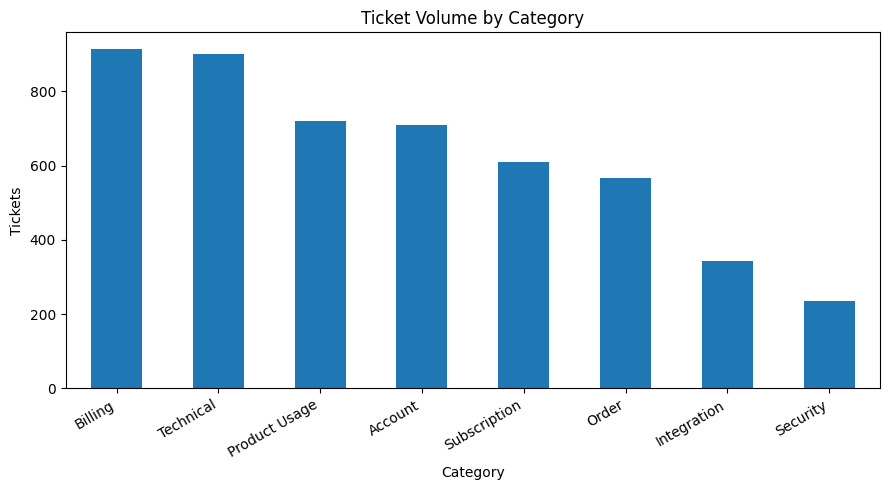

In [5]:
category_volume = df['category'].value_counts().rename_axis('category').reset_index(name='tickets')
category_volume['share_pct'] = category_volume['tickets'] / len(df) * 100
display(category_volume)

category_volume.plot.bar(x='category', y='tickets', legend=False, figsize=(9,5))
plt.title('Ticket Volume by Category')
plt.ylabel('Tickets')
plt.xlabel('Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Resolution Performance

,tickets,avg_resolution_hours,median_resolution_hours
category,,,
Security,234,22.63,20.39
Integration,344,21.83,18.87
Technical,901,19.74,17.06
Order,567,8.68,7.53
Subscription,610,7.22,6.16
Billing,913,6.42,5.50
Product Usage,721,5.91,5.08
Account,710,4.24,3.68


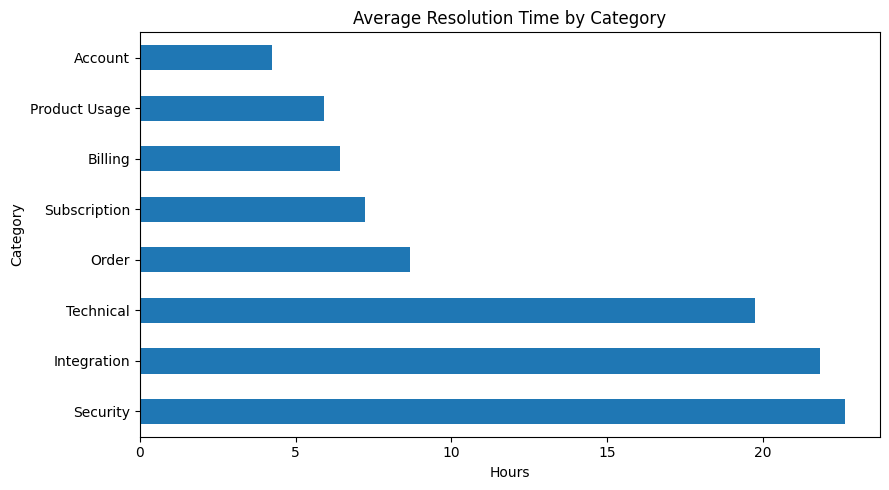

In [6]:
resolution_by_category = (
    df.groupby('category')
      .agg(tickets=('ticket_id','count'), avg_resolution_hours=('resolution_time_hours','mean'), median_resolution_hours=('resolution_time_hours','median'))
      .sort_values('avg_resolution_hours', ascending=False)
)
display(resolution_by_category)

resolution_by_category['avg_resolution_hours'].plot.barh(figsize=(9,5))
plt.title('Average Resolution Time by Category')
plt.xlabel('Hours')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## 5. Priority and Resolution Time

In [7]:
priority_order = ['Low', 'Medium', 'High', 'Critical']
priority_perf = (
    df.groupby('priority')
      .agg(tickets=('ticket_id','count'), avg_resolution_hours=('resolution_time_hours','mean'), sla_breach_rate=('sla_breached','mean'), escalation_rate=('escalated','mean'))
      .reindex(priority_order)
)
priority_perf['sla_breach_rate'] *= 100
priority_perf['escalation_rate'] *= 100
display(priority_perf)

,tickets,avg_resolution_hours,sla_breach_rate,escalation_rate
priority,,,,
Low,931,4.81,3.01,5.05
Medium,1839,7.49,3.10,8.70
High,1593,12.78,27.68,21.09
Critical,637,22.65,82.89,29.67


## 6. Escalation Analysis

,tickets,escalated_tickets,escalation_rate
category,,,
Security,234,88,37.61
Technical,901,273,30.30
Integration,344,104,30.23
Account,710,64,9.01
Product Usage,721,56,7.77
Order,567,41,7.23
Subscription,610,43,7.05
Billing,913,63,6.90


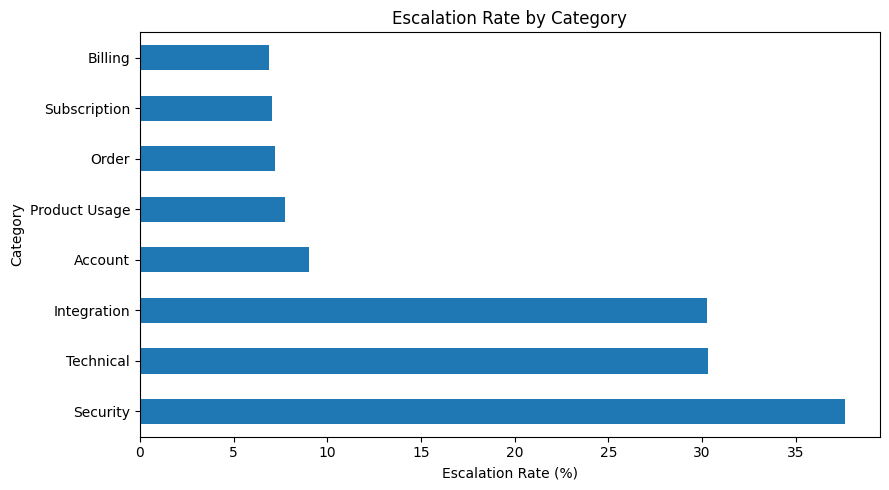

In [8]:
escalation_by_category = (
    df.groupby('category')
      .agg(tickets=('ticket_id','count'), escalated_tickets=('escalated','sum'), escalation_rate=('escalated','mean'))
      .sort_values('escalation_rate', ascending=False)
)
escalation_by_category['escalation_rate'] *= 100
display(escalation_by_category)

escalation_by_category['escalation_rate'].plot.barh(figsize=(9,5))
plt.title('Escalation Rate by Category')
plt.xlabel('Escalation Rate (%)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## 7. SLA Breach Analysis

In [9]:
sla_by_category = (
    df.groupby('category')
      .agg(tickets=('ticket_id','count'), sla_breaches=('sla_breached','sum'), sla_breach_rate=('sla_breached','mean'))
      .sort_values('sla_breach_rate', ascending=False)
)
sla_by_category['sla_breach_rate'] *= 100
display(sla_by_category)

,tickets,sla_breaches,sla_breach_rate
category,,,
Integration,344,198,57.56
Security,234,122,52.14
Technical,901,423,46.95
Order,567,67,11.82
Billing,913,85,9.31
Subscription,610,55,9.02
Product Usage,721,56,7.77
Account,710,48,6.76


## 8. Repeat Contacts and Reopened Tickets

In [10]:
repeat_analysis = (
    df.groupby('category')
      .agg(tickets=('ticket_id','count'), repeat_contact_rate=('repeat_contact','mean'), reopen_rate=('reopened','mean'), avg_csat=('csat_score','mean'))
      .sort_values('repeat_contact_rate', ascending=False)
)
repeat_analysis[['repeat_contact_rate','reopen_rate']] *= 100
display(repeat_analysis)

,tickets,repeat_contact_rate,reopen_rate,avg_csat
category,,,,
Integration,344,13.37,15.12,3.65
Technical,901,13.32,9.77,3.80
Billing,913,12.49,4.16,4.16
Account,710,6.20,4.51,4.19
Security,234,5.13,4.27,3.79
Subscription,610,4.75,3.44,4.15
Product Usage,721,4.30,4.44,4.17
Order,567,3.88,3.88,4.11


## 9. Customer Experience

In [11]:
csat_by_category = (
    df.groupby('category')
      .agg(tickets=('ticket_id','count'), avg_csat=('csat_score','mean'), avg_resolution_hours=('resolution_time_hours','mean'))
      .sort_values('avg_csat')
)
display(csat_by_category)

,tickets,avg_csat,avg_resolution_hours
category,,,
Integration,344,3.65,21.83
Security,234,3.79,22.63
Technical,901,3.80,19.74
Order,567,4.11,8.68
Subscription,610,4.15,7.22
Billing,913,4.16,6.42
Product Usage,721,4.17,5.91
Account,710,4.19,4.24


## 10. Business Insights → Product Opportunities

Use the outputs above to document evidence-backed product implications. The table below is intentionally a template so conclusions come from the observed data rather than assumptions.

In [12]:
# Automatically surface the highest-risk segments for review
top_resolution = resolution_by_category.head(3)
top_escalation = escalation_by_category.head(3)
top_sla = sla_by_category.head(3)

print('Categories with highest average resolution time:')
display(top_resolution)

print('Categories with highest escalation rate:')
display(top_escalation)

print('Categories with highest SLA breach rate:')
display(top_sla)

Categories with highest average resolution time:


,tickets,avg_resolution_hours,median_resolution_hours
category,,,
Security,234,22.63,20.39
Integration,344,21.83,18.87
Technical,901,19.74,17.06


Categories with highest escalation rate:


,tickets,escalated_tickets,escalation_rate
category,,,
Security,234,88,37.61
Technical,901,273,30.30
Integration,344,104,30.23


Categories with highest SLA breach rate:


,tickets,sla_breaches,sla_breach_rate
category,,,
Integration,344,198,57.56
Security,234,122,52.14
Technical,901,423,46.95


### Product implication framework

| Data finding | Business problem | Product opportunity | Candidate AI capability |
|---|---|---|---|
| Highest-resolution-time category | Agents spend more time investigating | Reduce investigation effort | Knowledge retrieval / next-action suggestions |
| Highest-escalation category | More tickets require specialist handoff | Improve handoff quality | Escalation summary |
| Highest-SLA-risk category | Greater operational risk | Identify urgent tickets earlier | Priority recommendation |
| High-volume category | Large support workload | Reduce repetitive triage | Classification + summarization |
| High-repeat-contact category | Customers return for unresolved issues | Improve first-contact resolution | Knowledge assistance |

**Important:** Replace these generic implications with the actual top categories and measured patterns after running the notebook.

## 11. BA/PM Conclusion

The final conclusion should answer three questions:

1. **Where is the largest operational pain?**
2. **Which AI capability directly addresses that pain?**
3. **Which KPI should improve if the capability works?**

The resulting evidence will be used to refine the MVP scope, product metrics, and prototype.